**Analysis of Expenditures** - Analysis Code Demo


**Introduction**

In this project, I analyze a dataset from the Georgia Department of Behavioral Health and Developmental Disabilities to see whether expenditures are allocated differently between Hispanic and White non-Hispanic consumers. The goal is to check if spending patterns suggest possible discrimination or bias. To do that, I first clean the dataset, create age cohorts, and then compare expenditures overall and within age groups to separate normal demographic differences from potential unequal allocation.

**Data Preprocessing**

Before running the analysis, I review the dataset and create a new categorical variable called Age Cohort. I group consumers into six age ranges (0–5, 6–12, 13–17, 18–21, 22–50, 51+) so I can compare expenditures within comparable life stages. This helps avoid misleading conclusions, since spending can naturally vary by age.

In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Expenditures"] = pd.to_numeric(df["Expenditures"], errors="coerce")
df["Gender"] = df["Gender"].astype(str).str.strip()
df["Ethnicity"] = df["Ethnicity"].astype(str).str.strip()

bins = [0, 5, 12, 17, 21, 50, np.inf]
labels = ["0-5", "6-12", "13-17", "18-21", "22-50", "51+"]

df["Age_Cohort"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

df["Age_Cohort"].value_counts().sort_index()

Age_Cohort
0-5       81
6-12     175
13-17    210
18-21    198
22-50    226
51+      106
Name: count, dtype: int64

**Analysis and Research Questions** 


**A) Data Quality**

I first check for missing or erroneous values in the key columns used in the analysis (Age, Gender, Ethnicity, Expenditures). Rows with missing values or invalid ages (negative ages) are removed so they do not distort the results. After that, I use the Interquartile Range (IQR) method to detect outliers in expenditures and remove those rows from further analysis.

In [38]:
before = len(df)

df_q = df.dropna(subset=["Age", "Gender", "Ethnicity", "Expenditures", "Age_Cohort"]).copy()
df_q = df_q[df_q["Age"] >= 0]

deleted_missing_erroneous = before - len(df_q)

# IQR outlier detection
q1 = df_q["Expenditures"].quantile(0.25)
q3 = df_q["Expenditures"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

before2 = len(df_q)
df_clean = df_q[(df_q["Expenditures"] >= lower) & (df_q["Expenditures"] <= upper)].copy()
deleted_outliers = before2 - len(df_clean)

print("Deleted rows (missing/erroneous):", deleted_missing_erroneous)
print("Deleted rows (IQR outliers):", deleted_outliers)

Deleted rows (missing/erroneous): 10
Deleted rows (IQR outliers): 0


**Box Plot (IQR visualization)**

To visualize the IQR approach, I used a box plot of expenditures. The box shows the middle 50% of values (between Q1 and Q3), the line inside the box is the median, and any points beyond the whiskers would represent potential outliers.

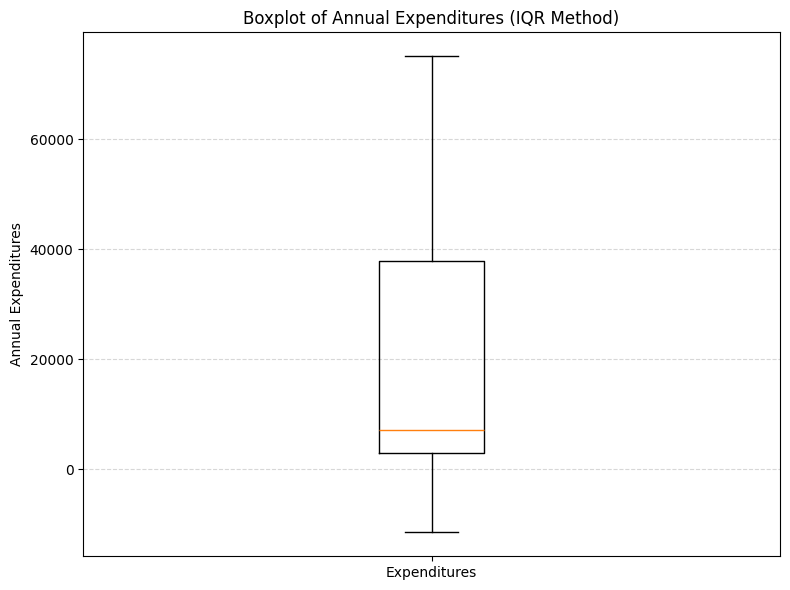

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot(df_q["Expenditures"], vert=True)
plt.title("Boxplot of Annual Expenditures (IQR Method)")
plt.ylabel("Annual Expenditures")
plt.xticks([1], ["Expenditures"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**B. Expenditure Analysis**

After cleaning, I calculated spending summaries to compare expenditures across groups. This includes average spending for key demographic groups, median spending by age cohort, a gender comparison (including the difference between male and female averages), and total annual expenditures by ethnicity.

In [40]:
avg_all_males = df_clean[df_clean["Gender"].str.lower() == "male"]["Expenditures"].mean()
print("Average expenditure - All males:", avg_all_males)

avg_all_hispanics = df_clean[df_clean["Ethnicity"].str.lower() == "hispanic"]["Expenditures"].mean()
print("Average expenditure - All Hispanics:", avg_all_hispanics)

avg_white_nonhisp_males = df_clean[
    (df_clean["Gender"].str.lower() == "male") &
    (df_clean["Ethnicity"].str.lower() == "white not hispanic")
]["Expenditures"].mean()
print("Average expenditure - All White non-Hispanic males:", avg_white_nonhisp_males)

median_by_age_cohort = df_clean.groupby("Age_Cohort")["Expenditures"].median()
print("\nMedian annual expenditure by age cohort:")
print(median_by_age_cohort)

avg_by_gender = df_clean.groupby(df_clean["Gender"].str.lower())["Expenditures"].mean().sort_values(ascending=False)
print("\nAverage expenditure by gender:")
print(avg_by_gender)

top_gender = avg_by_gender.index[0]
print("Gender with highest average annual expenditure:", top_gender)

avg_male = df_clean[df_clean["Gender"].str.lower() == "male"]["Expenditures"].mean()
avg_female = df_clean[df_clean["Gender"].str.lower() == "female"]["Expenditures"].mean()
gender_diff_male_minus_female = avg_male - avg_female
print("Difference (male - female):", gender_diff_male_minus_female)

total_by_ethnicity = df_clean.groupby("Ethnicity")["Expenditures"].sum().sort_values(ascending=False)
print("\nTotal annual expenditures by ethnic group:")
print(total_by_ethnicity)

Average expenditure - All males: 18041.717479674797
Average expenditure - All Hispanics: 11078.010666666667
Average expenditure - All White non-Hispanic males: 24573.79591836735

Median annual expenditure by age cohort:
Age_Cohort
0-5       1380.5
6-12      2191.0
13-17     3968.0
18-21     9975.5
22-50    40517.0
51+      53509.0
Name: Expenditures, dtype: float64

Average expenditure by gender:
Gender
female    18265.178715
male      18041.717480
Name: Expenditures, dtype: float64
Gender with highest average annual expenditure: female
Difference (male - female): -223.46123518464083

Total annual expenditures by ethnic group:
Ethnicity
White not Hispanic    9903377
Hispanic              4154254
Asian                 2334516
Black                 1198142
American Indian        145753
Native Hawaiian        128347
Multi Race             101562
Other                    6633
Name: Expenditures, dtype: int64


**C. Demographic Analysis**

To understand who is represented in the dataset, I looked at demographic counts. First, I identified which ethnic group has the highest number of consumers within the 22–50 age cohort. Then, I determined the most populous age cohort for each gender.

In [41]:
eth_counts_22_50 = df_clean[df_clean["Age_Cohort"] == "22-50"]["Ethnicity"].value_counts()
print("Ethnic group counts in 22–50 cohort:")
print(eth_counts_22_50)

top_ethnicity_22_50 = eth_counts_22_50.idxmax()
print("\nEthnic group with the highest number of consumers in 22–50 cohort:", top_ethnicity_22_50)

gender_cohort_counts = (
    df_clean.groupby(["Gender", "Age_Cohort"])
    .size()
    .reset_index(name="Count")
)
most_populous_cohort_by_gender = (
    gender_cohort_counts.sort_values("Count", ascending=False)
    .groupby("Gender")
    .first()
    .reset_index()
)
print("\nMost populous age cohort for each gender:")
print(most_populous_cohort_by_gender)

Ethnic group counts in 22–50 cohort:
Ethnicity
White not Hispanic    133
Hispanic               43
Asian                  28
Black                  17
Native Hawaiian         2
Multi Race              1
American Indian         1
Name: count, dtype: int64

Ethnic group with the highest number of consumers in 22–50 cohort: White not Hispanic

Most populous age cohort for each gender:
   Gender Age_Cohort  Count
0  Female      13-17    105
1    Male      22-50    120



**D. Main Question: Is There Discrimination/Bias?**

In this section, I compare Hispanic and White non-Hispanic consumers to determine whether there is evidence of disparities in the allocation of expenditures. First, I calculate the percentage representation of each group in the dataset. Then, I compare total and average expenditures between the two groups. Finally, I analyze expenditures across age cohorts to determine whether differences persist when age is considered.

**Percentage Consumers**

In [42]:
ethnicity_counts = df_clean["Ethnicity"].value_counts()

total_customers = len(df_clean)

hispanic_percent = (ethnicity_counts.get("Hispanic", 0) / total_customers) * 100
print("Percentage Hispanic:", f"{hispanic_percent:.2f}%")

white_nonhisp_percent = (ethnicity_counts.get("White not Hispanic", 0) / total_customers) * 100
print("Percentage White non-Hispanic:",f"{white_nonhisp_percent:.2f}%")

Percentage Hispanic: 37.88%
Percentage White non-Hispanic: 40.40%


**Compare Expenditures Between Groups**

In [43]:
# Filtering groups
hispanic = df_clean[df_clean["Ethnicity"] == "Hispanic"]
white_nonhisp = df_clean[df_clean["Ethnicity"] == "White not Hispanic"]

# Average expenditure
avg_hispanic = hispanic["Expenditures"].mean()
print("Average Expenditure Hispanic:", f"{avg_hispanic:.2f}")

avg_white_nonhisp = white_nonhisp["Expenditures"].mean()
print("Average Expenditure White non-Hispanic:", f"{avg_white_nonhisp:.2f}")

# Total expenditure
total_hispanic = hispanic["Expenditures"].sum()
print("\nTotal Expenditure Hispanic:", total_hispanic)

total_white_nonhisp = white_nonhisp["Expenditures"].sum()
print("Total Expenditure White non-Hispanic:", total_white_nonhisp)

Average Expenditure Hispanic: 11078.01
Average Expenditure White non-Hispanic: 24758.44

Total Expenditure Hispanic: 4154254
Total Expenditure White non-Hispanic: 9903377


**Expenditures by Age Cohort**

In [44]:
cohort_comparison = (
    df_clean[df_clean["Ethnicity"].isin(["Hispanic", "White not Hispanic"])]
    .groupby(["Age_Cohort", "Ethnicity"])["Expenditures"]
    .mean()
    .unstack()
)

print("Average expenditures by age cohort:")
print(cohort_comparison)

Average expenditures by age cohort:
Ethnicity       Hispanic  White not Hispanic
Age_Cohort                                  
0-5          1393.204545         1420.947368
6-12         2312.186813         2052.260870
13-17        3955.281553         3904.358209
18-21       10006.077922        10133.057971
22-50       40924.116279        40187.624060
51+         55585.000000        52670.424242


**Visualization**

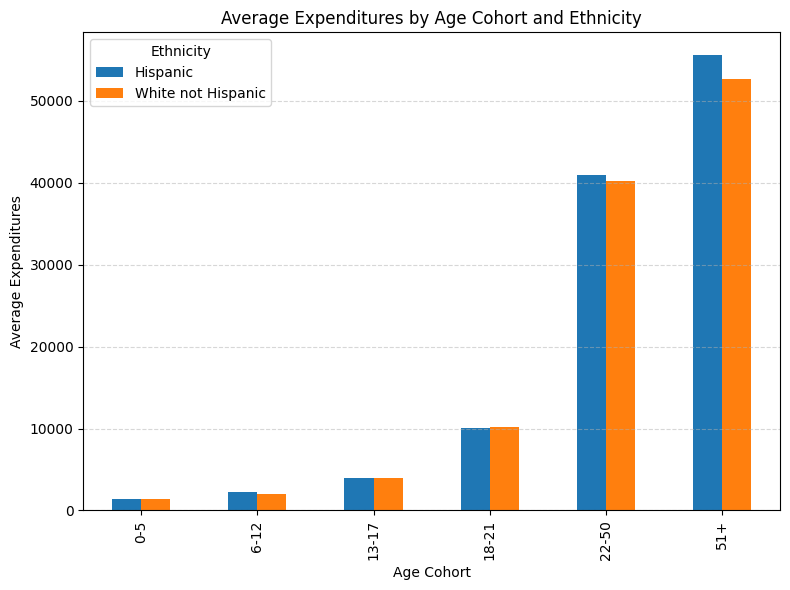

In [45]:
import matplotlib.pyplot as plt

cohort_comparison.plot(kind="bar", figsize=(8,6))

plt.title("Average Expenditures by Age Cohort and Ethnicity")
plt.ylabel("Average Expenditures")
plt.xlabel("Age Cohort")
plt.legend(title="Ethnicity")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()